# 🔬 Cancer Detection using CNN
### Transfer Learning with EfficientNetB0
**Dataset:** Histopathologic Cancer Detection (Kaggle)
**Task:** Binary Classification — Cancerous vs Non-Cancerous Tissue

## 📦 Step 1 — Install Dependencies

In [1]:
!pip install kaggle -q
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings; warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 🔑 Step 2 — Upload kaggle.json API Key

In [2]:
from google.colab import files
files.upload()   # upload your kaggle.json here

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✅ Kaggle API key configured!")

Saving kaggle.json to kaggle.json
✅ Kaggle API key configured!


## 📥 Step 3 — Download Dataset
> ⚠️ First accept competition rules at: https://www.kaggle.com/competitions/histopathologic-cancer-detection/rules

In [3]:
!kaggle competitions download -c histopathologic-cancer-detection -p /content/
!unzip -q /content/histopathologic-cancer-detection.zip -d /content/data/
!ls /content/data/

100% 6.31G/6.31G [01:15<00:00, 89.6MB/s]

sample_submission.csv  test  train  train_labels.csv


## ⚙️ Step 4 — Configuration

In [4]:
DATA_DIR   = '/content/data'
TRAIN_DIR  = os.path.join(DATA_DIR, 'train')
LABELS_CSV = os.path.join(DATA_DIR, 'train_labels.csv')
IMG_SIZE   = 96; BATCH_SIZE = 64; EPOCHS = 20; LEARNING_RATE = 1e-4
USE_SUBSET = True; SUBSET_FRAC = 0.20; SEED = 42
tf.random.set_seed(SEED); np.random.seed(SEED)

## 📁 Step 5 — Load & Explore Labels

Total samples: 220025
label
0    130908
1     89117
Name: count, dtype: int64


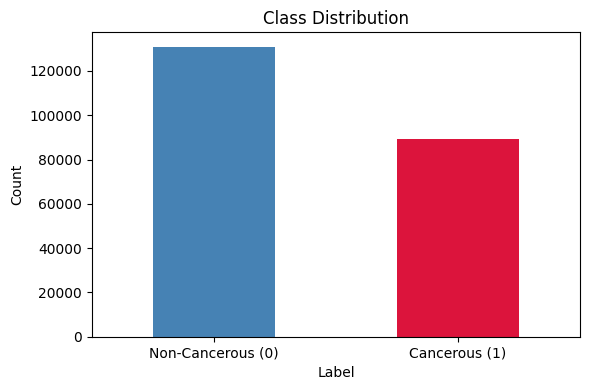

In [5]:
df = pd.read_csv(LABELS_CSV)
df['filename'] = df['id'] + '.tif'
df['label'] = df['label'].astype(str)
print(f"Total samples: {len(df)}")
print(df['label'].value_counts())

plt.figure(figsize=(6,4))
df['label'].value_counts().plot(kind='bar', color=['steelblue','crimson'], rot=0)
plt.title('Class Distribution'); plt.xlabel('Label'); plt.ylabel('Count')
plt.xticks([0,1], ['Non-Cancerous (0)','Cancerous (1)'])
plt.tight_layout(); plt.show()

## 🔄 Step 6 — Prepare DataFrames (with optional subset)

In [6]:
if USE_SUBSET:
    df, _ = train_test_split(df, test_size=1-SUBSET_FRAC, stratify=df['label'], random_state=SEED)
    print(f"Using subset: {len(df)} samples ({SUBSET_FRAC*100:.0f}%)")

train_df, test_df = train_test_split(df, test_size=0.15, stratify=df['label'], random_state=SEED)
train_df, val_df  = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=SEED)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Using subset: 44005 samples (20%)
Train: 33663 | Val: 3741 | Test: 6601


## 📁 Step 7 — Data Generators + Augmentation

In [7]:
train_datagen = ImageDataGenerator(rescale=1/255, rotation_range=180,
    horizontal_flip=True, vertical_flip=True,
    width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, fill_mode='reflect')
vt_datagen = ImageDataGenerator(rescale=1/255)

train_gen = train_datagen.flow_from_dataframe(train_df, directory=TRAIN_DIR,
    x_col='filename', y_col='label', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', seed=SEED)
val_gen   = vt_datagen.flow_from_dataframe(val_df, directory=TRAIN_DIR,
    x_col='filename', y_col='label', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)
test_gen  = vt_datagen.flow_from_dataframe(test_df, directory=TRAIN_DIR,
    x_col='filename', y_col='label', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='binary', shuffle=False)

Found 33663 validated image filenames belonging to 2 classes.
Found 3741 validated image filenames belonging to 2 classes.
Found 6601 validated image filenames belonging to 2 classes.


## 🔍 Step 8 — Visualize Sample Patches

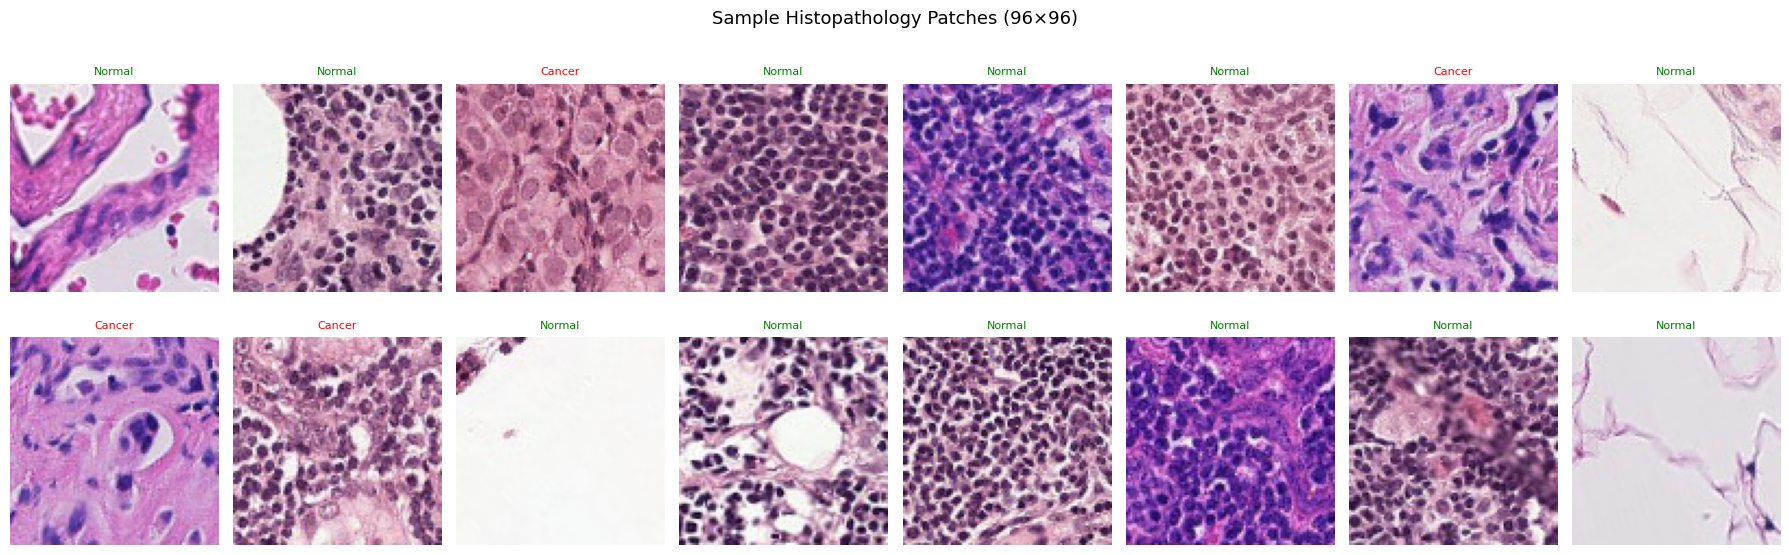

In [8]:
X_b, y_b = next(train_gen)
fig, axes = plt.subplots(2, 8, figsize=(18, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_b[i])
    lbl = 'Cancer' if y_b[i]==1 else 'Normal'
    ax.set_title(lbl, color='red' if y_b[i]==1 else 'green', fontsize=8); ax.axis('off')
plt.suptitle('Sample Histopathology Patches (96×96)', fontsize=13)
plt.tight_layout(); plt.show()

## 🏗️ Step 9 — Build Model (EfficientNetB0 + Custom Head)

In [9]:
base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
for layer in base.layers[:-30]: layer.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x   = base(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.BatchNormalization()(x)
x   = layers.Dropout(0.5)(x)
x   = layers.Dense(64, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inp, out)
model.compile(optimizer=optimizers.Adam(LEARNING_RATE),
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3, 3, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,395,044 (16.77 MB)

 Trainable params: 1,841,121 (7.02 MB)

 Non-trainable params: 2,553,923 (9.74 MB)

## ⚖️ Step 10 — Class Weights (handle imbalance)

In [10]:
lbl_arr = train_df['label'].astype(int).values
cw = compute_class_weight('balanced', classes=np.unique(lbl_arr), y=lbl_arr)
class_weights = {0: cw[0], 1: cw[1]}
print(f"Class weights: {class_weights}")

Class weights: {0: np.float64(0.8403564830995057), 1: np.float64(1.234523984157254)}


## 🚀 Step 11 — Train

In [11]:
cb_list = [
    callbacks.EarlyStopping(monitor='val_auc', patience=5,
                             restore_best_weights=True, mode='max', verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5,
                                 patience=3, mode='max', verbose=1),
    callbacks.ModelCheckpoint('/content/cancer_best.h5', monitor='val_auc',
                               save_best_only=True, mode='max', verbose=1)
]
history = model.fit(train_gen, validation_data=val_gen, epochs=EPOCHS,
                    class_weight=class_weights, callbacks=cb_list)

Epoch 1/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5153 - auc: 0.5270 - loss: 0.8894
Epoch 1: val_auc improved from None to 0.71218, saving model to /content/cancer_best.h5



Epoch 1: finished saving model to /content/cancer_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 783s 1s/step - accuracy: 0.5290 - auc: 0.5456 - loss: 0.8417 - val_accuracy: 0.5950 - val_auc: 0.7122 - val_loss: 0.6378 - learning_rate: 1.0000e-04
Epoch 2/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5526 - auc: 0.5791 - loss: 0.7667
Epoch 2: val_auc did not improve from 0.71218
526/526 ━━━━━━━━━━━━━━━━━━━━ 718s 1s/step - accuracy: 0.5598 - auc: 0.5885 - loss: 0.7532 - val_accuracy: 0.5998 - val_auc: 0.6832 - val_loss: 0.6283 - learning_rate: 1.0000e-04
Epoch 3/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5725 - auc: 0.6084 - loss: 0.7255
Epoch 3: val_auc improved from 0.71218 to 0.75476, saving model to /content/cancer_best.h5



Epoch 3: finished saving model to /content/cancer_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.5751 - auc: 0.6130 - loss: 0.7193 - val_accuracy: 0.6100 - val_auc: 0.7548 - val_loss: 0.6456 - learning_rate: 1.0000e-04
Epoch 4/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5925 - auc: 0.6396 - loss: 0.6889
Epoch 4: val_auc improved from 0.75476 to 0.76441, saving model to /content/cancer_best.h5



Epoch 4: finished saving model to /content/cancer_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 726s 1s/step - accuracy: 0.5943 - auc: 0.6409 - loss: 0.6862 - val_accuracy: 0.6790 - val_auc: 0.7644 - val_loss: 0.6083 - learning_rate: 1.0000e-04
Epoch 5/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5969 - auc: 0.6491 - loss: 0.6750
Epoch 5: val_auc improved from 0.76441 to 0.76938, saving model to /content/cancer_best.h5



Epoch 5: finished saving model to /content/cancer_best.h5
526/526 ━━━━━━━━━━━━━━━━━━━━ 723s 1s/step - accuracy: 0.6023 - auc: 0.6566 - loss: 0.6695 - val_accuracy: 0.7036 - val_auc: 0.7694 - val_loss: 0.5785 - learning_rate: 1.0000e-04
Epoch 6/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6091 - auc: 0.6673 - loss: 0.6590
Epoch 6: val_auc did not improve from 0.76938
526/526 ━━━━━━━━━━━━━━━━━━━━ 722s 1s/step - accuracy: 0.6137 - auc: 0.6717 - loss: 0.6557 - val_accuracy: 0.6522 - val_auc: 0.7217 - val_loss: 0.5899 - learning_rate: 1.0000e-04
Epoch 7/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6233 - auc: 0.6870 - loss: 0.6401
Epoch 7: val_auc did not improve from 0.76938
526/526 ━━━━━━━━━━━━━━━━━━━━ 711s 1s/step - accuracy: 0.6222 - auc: 0.6862 - loss: 0.6421 - val_accuracy: 0.6111 - val_auc: 0.6734 - val_loss: 0.6222 - learning_rate: 1.0000e-04
Epoch 8/20
526/526 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6222 - auc: 0.6888 - loss: 0.6412
Epoch 8: ReduceLRO

## 📈 Step 12 — Training Curves

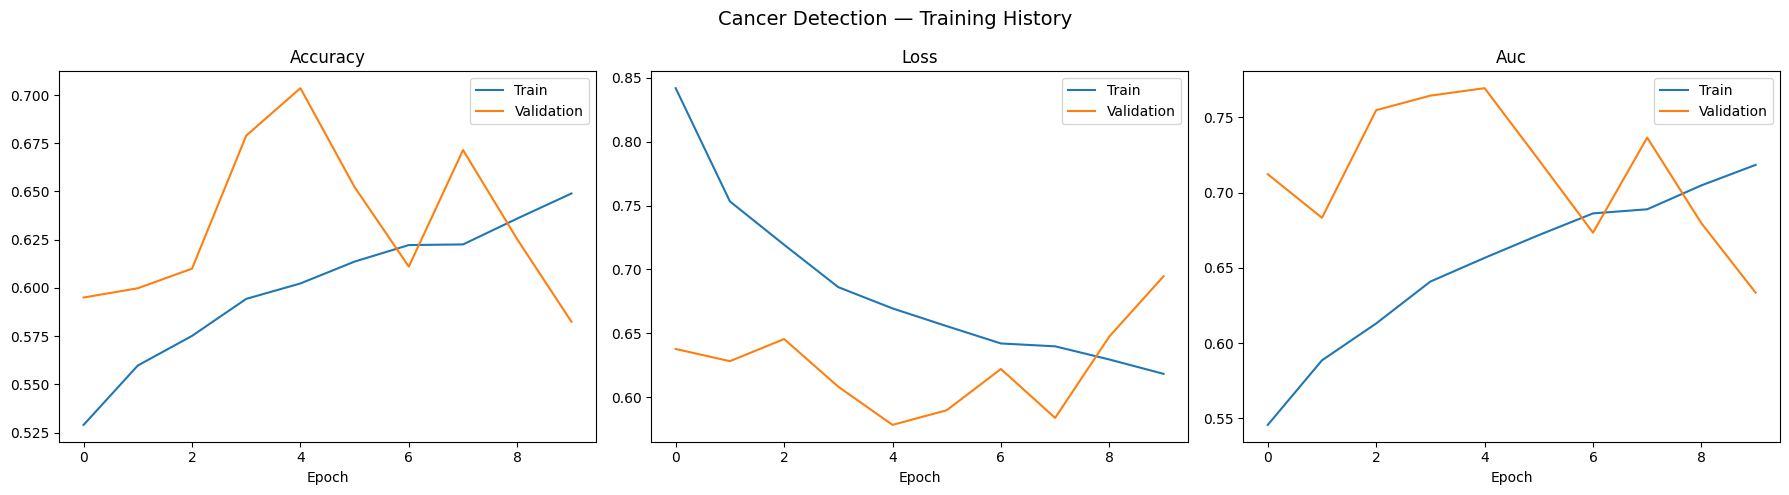

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['accuracy', 'loss', 'auc']):
    ax.plot(history.history[metric], label='Train')
    ax.plot(history.history[f'val_{metric}'], label='Validation')
    ax.set_title(metric.capitalize()); ax.set_xlabel('Epoch'); ax.legend()
plt.suptitle('Cancer Detection — Training History', fontsize=14)
plt.tight_layout(); plt.show()

## 🧪 Step 13 — Evaluate

In [14]:
res = model.evaluate(test_gen, verbose=0)
print(f"\n✅ Test Accuracy: {res[1]*100:.2f}%  |  AUC: {res[2]:.4f}")

test_gen.reset()
y_prob = model.predict(test_gen).flatten()
y_pred = (y_prob >= 0.5).astype(int)
y_true = np.array(test_gen.labels).astype(int)
print("\n📊 Classification Report:")
print(classification_report(y_true, y_pred, target_names=['Non-Cancerous','Cancerous']))


✅ Test Accuracy: 70.82%  |  AUC: 0.7688
104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 845ms/step

📊 Classification Report:
               precision    recall  f1-score   support

Non-Cancerous       0.81      0.67      0.73      3927
    Cancerous       0.61      0.76      0.68      2674

     accuracy                           0.71      6601
    macro avg       0.71      0.72      0.71      6601
 weighted avg       0.73      0.71      0.71      6601



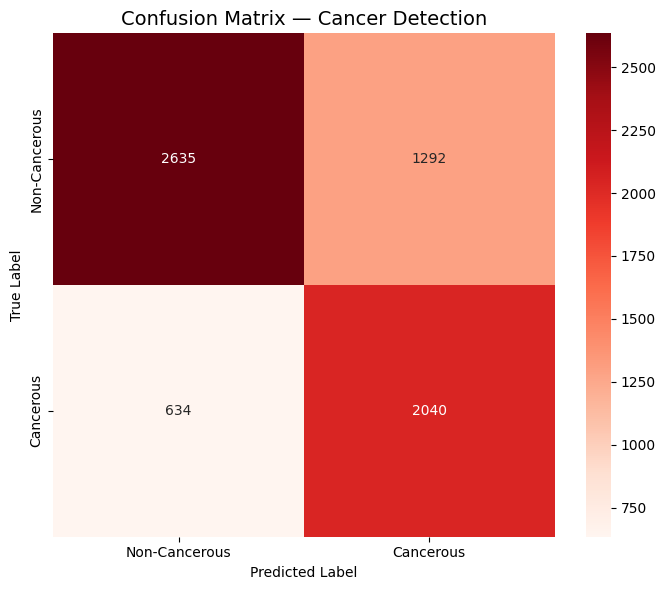

In [15]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Non-Cancerous','Cancerous'],
            yticklabels=['Non-Cancerous','Cancerous'])
plt.title('Confusion Matrix — Cancer Detection', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

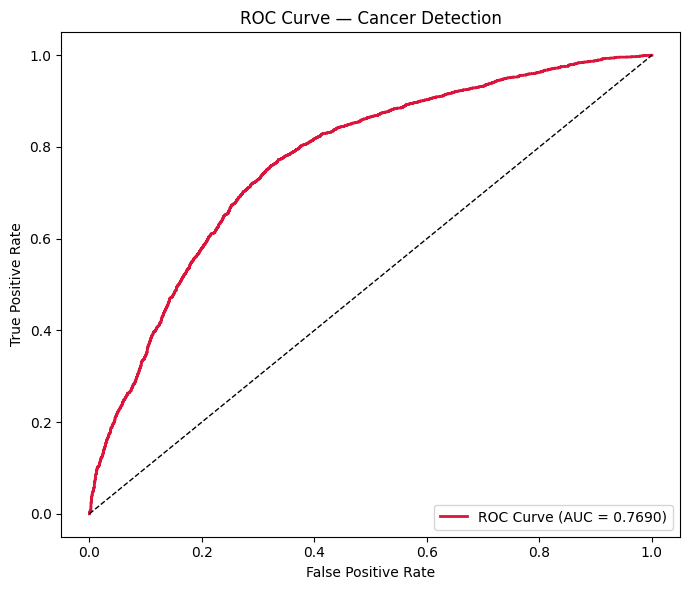

In [16]:
fpr, tpr, _ = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Cancer Detection')
plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

In [17]:
model.save('/content/cancer_detection_final.h5')
print("✅ Model saved to /content/cancer_detection_final.h5")

✅ Model saved to /content/cancer_detection_final.h5
